# **Credit Card Fraud Detection**

### Credit card fraud is one of the most significant financial risks facing retail banks today. As transaction volumes grow, fraudulent activity becomes increasingly difficult to detect manually, resulting in direct financial losses and erosion of customer trust. Early identification of fraud patterns is critical for banks to strengthen detection controls and protect their customers proactively.

### This report analyses 555,719 credit card transactions to uncover patterns and trends in fraudulent activity. The objective is to provide the fraud risk management team with a clear, evidence-based view of where fraud concentrates — across time, merchant categories, geography, and customer demographics — so that targeted interventions and risk controls can be prioritised accordingly.

# **Dataset:**

### **Source**: Simulated Credit Card Transactions Dataset (Kaggle)
### **Target variable**: is_fraud (0 = legit, 1 = fraud)


In [ ]:
# Download library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Credit Card Fraud Detection/fraudTest.csv')
df

Mounted at /content/drive


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Questions:
1. What is the overall fraud rate in the transaction portfolio, and does it indicate an elevated risk exposure that requires immediate attention?

2. How does fraudulent activity fluctuate across time — by quarter, month, time in day — and what seasonal or behavioural patterns can inform when monitoring should be intensified?

3. Which categories carry the highest concentration of fraudulent transactions, and what transaction controls could be introduced to mitigate category-specific risk?

4. Which states represent the highest fraud exposure?

5. How is fraud distributed across customer age groups and gender, and are there specific demographic segments that require enhanced protective measures or targeted fraud awareness communication?

In [ ]:
# Explore the dataset
print(df.shape)
print(df.columns)
print(df.dtypes)

(555719, 23)
Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                floa

- 555719 transactions
- 23 columns

Columns to use:
- trans_date_trans_time
- category
- gender
- dob
- city
- state
- is_fraud


In [ ]:
# Check missing values
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


The dataset is clean and does not need to clean and fix.

# Overall fraud rate

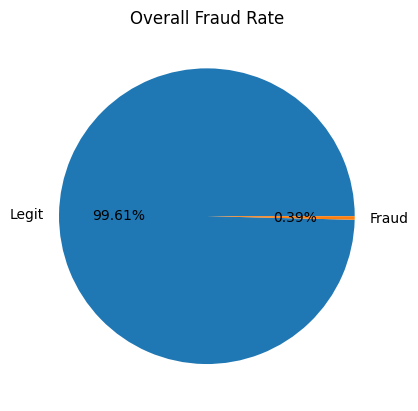

In [ ]:
# Rate of fraud transactions
fraud_count = df['is_fraud'].value_counts()
fraud_rate = fraud_count[1] / (fraud_count[0] + fraud_count[1])

labels = ['Legit', 'Fraud']

plt.pie(fraud_count, labels = ['Legit', 'Fraud'], autopct='%1.2f%%')
plt.title('Overall Fraud Rate')
plt.show()

In [ ]:
fraud_sum = df.groupby('is_fraud')['amt'].sum()
print(fraud_sum)

#Fraud rate by transaction value (basic points - bps)
fraud_rate_bps = (fraud_sum[1] / df['amt'].sum()) * 10000
print(f'Fraud Rate bps: {fraud_rate_bps:1.2f}')

is_fraud
0    37429578.43
1     1133324.68
Name: amt, dtype: float64
Fraud Rate bps: 293.89


**Transaction Count Rate: 0.39% (2,145 out of 555,719 transactions)**  
**Fraud Loss Rate: 293.89 basis points (bps)**

At first glance, the fraud transaction rate of 0.39% appears negligible — less than 4 in every 1,000 transactions are fraudulent. By transaction count alone, this could suggest that the bank's detection and verification processes are functioning adequately.

However, when fraud is measured by transaction value — the metric used by U.S. regulators and the payments industry — a significantly more concerning picture emerges. The bank's fraud loss rate stands at 293.89 basis points, compared to the U.S. industry benchmark of approximately 6.81 basis points reported by *WalletHub* and the Federal Reserve. This places the bank's value-based fraudexposure at approximately 43 times the national average.

The low transaction count rate should not be interpreted as a sign that fraud is under control. The elevated basis point rate signals that the bank faces a high-severity, low-frequency fraud problem — a pattern that is often harder to detect and more costly per incident than high-frequency small-amount fraud. Immediate further investigation is recommended into which merchant categories and customer segments are driving these high-value fraudulent transactions, which will be explored in the following sections of this report.


# Time Series Analysis

### Fraud Amount Proportion by Quarter

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['quarter'] = df['trans_date_trans_time'].dt.quarter

quarterly_total_amount = df.groupby('quarter')['amt'].sum()
quarterly_fraud_amount = df[df['is_fraud'] == 1].groupby('quarter')['amt'].sum()

quarterly_fraud_proportion = (quarterly_fraud_amount / quarterly_total_amount) * 100

print(quarterly_fraud_proportion.round(2))

quarter
2    3.52
3    3.36
4    2.51
Name: amt, dtype: float64


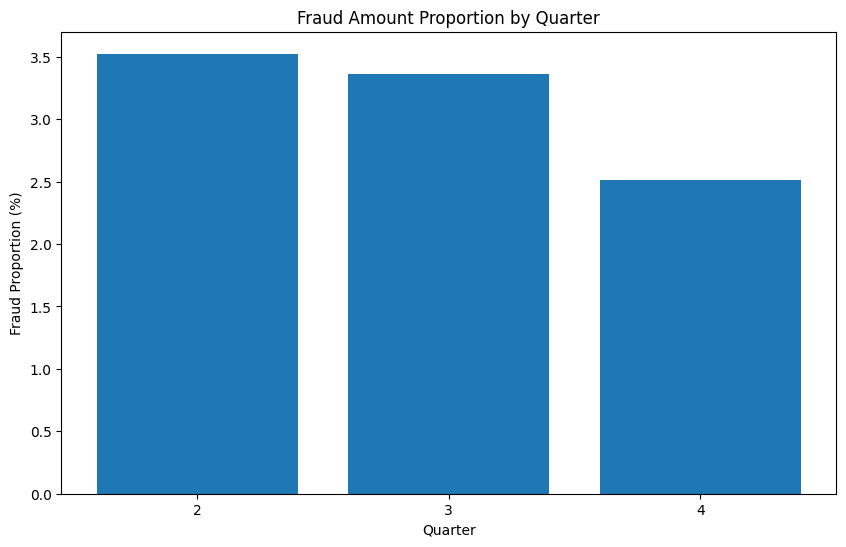

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(quarterly_fraud_proportion.index, quarterly_fraud_proportion.values)
plt.title('Fraud Amount Proportion by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Fraud Proportion (%)')
plt.xticks(quarterly_fraud_proportion.index)
plt.show()

In [ ]:
df['month'] = df['trans_date_trans_time'].dt.month

monthly_fraud_amount = df[df['is_fraud'] == 1].groupby('month')['amt'].sum()
monthly_total_amount = df.groupby('month')['amt'].sum()

monthly_fraud_proportion = (monthly_fraud_amount / monthly_total_amount) * 100

print(monthly_fraud_proportion.round(2))

month
6     3.52
7     2.67
8     3.40
9     4.13
10    4.02
11    3.05
12    1.47
Name: amt, dtype: float64


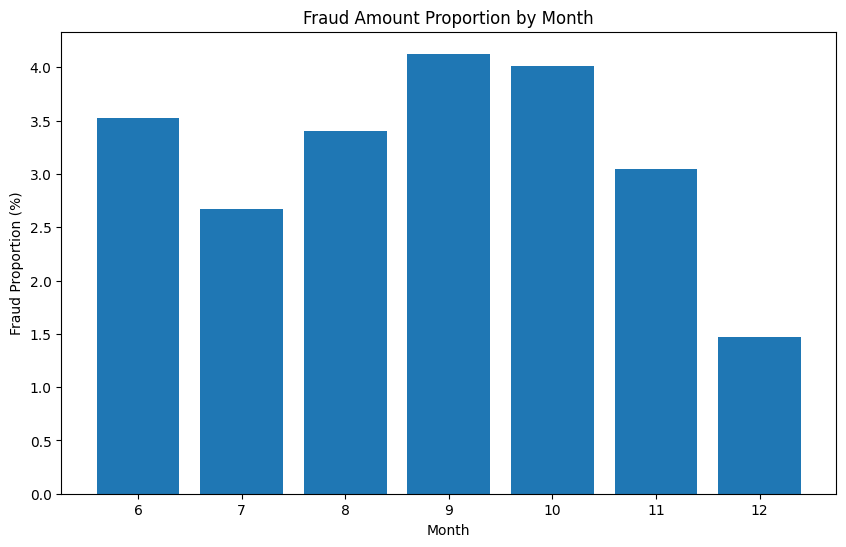

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(monthly_fraud_proportion.index, monthly_fraud_proportion.values)
plt.title('Fraud Amount Proportion by Month')
plt.xlabel('Month')
plt.ylabel('Fraud Proportion (%)')
plt.show()

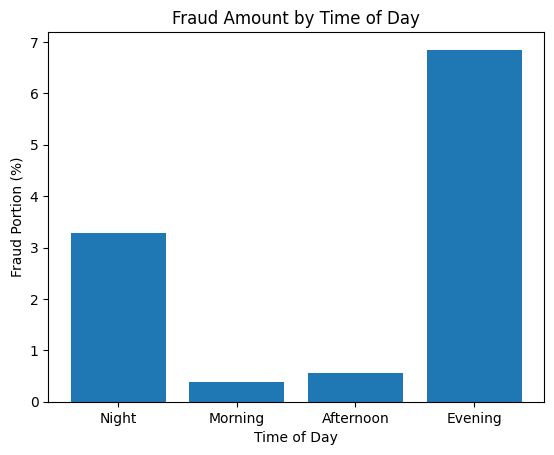

In [ ]:
df['hour'] = df['trans_date_trans_time'].dt.hour

def time_of_day_bin(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['time_of_day'] = df['hour'].apply(time_of_day_bin)

fraud_by_time = df[df['is_fraud'] == 1].groupby('time_of_day')['amt'].sum().reindex([
    'Night', 'Morning', 'Afternoon', 'Evening'
])
total_by_time = df.groupby('time_of_day')['amt'].sum().reindex(['Night', 'Morning', 'Afternoon', 'Evening'])
fraud_by_time_portion = (fraud_by_time / total_by_time) * 100

plt.bar(fraud_by_time_portion.index, fraud_by_time_portion.values)
plt.title('Fraud Amount by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Fraud Portion (%)')
plt.show()

Two clear risk windows emerge from this analysis. First, the bank should treat September and October as elevated-risk months seasonally, intensifying monitoring and review capacity during this period. Second, and more urgently, the Evening timeframe (18:00–23:59) represents a critical vulnerability — fraudsters appear to deliberately operate outside business hours when human oversight and customer responsiveness are lowest.

# Category

In [ ]:
fraud_by_category = df[df['is_fraud'] == 1].groupby('category')['amt'].sum().sort_values(ascending=False)
fraud_by_category

,amt
category,
shopping_net,503123.93
misc_net,214742.95
shopping_pos,188887.25
grocery_pos,151866.72
entertainment,30076.17
home,17260.30
misc_pos,13923.82
food_dining,6607.54
gas_transport,1848.42


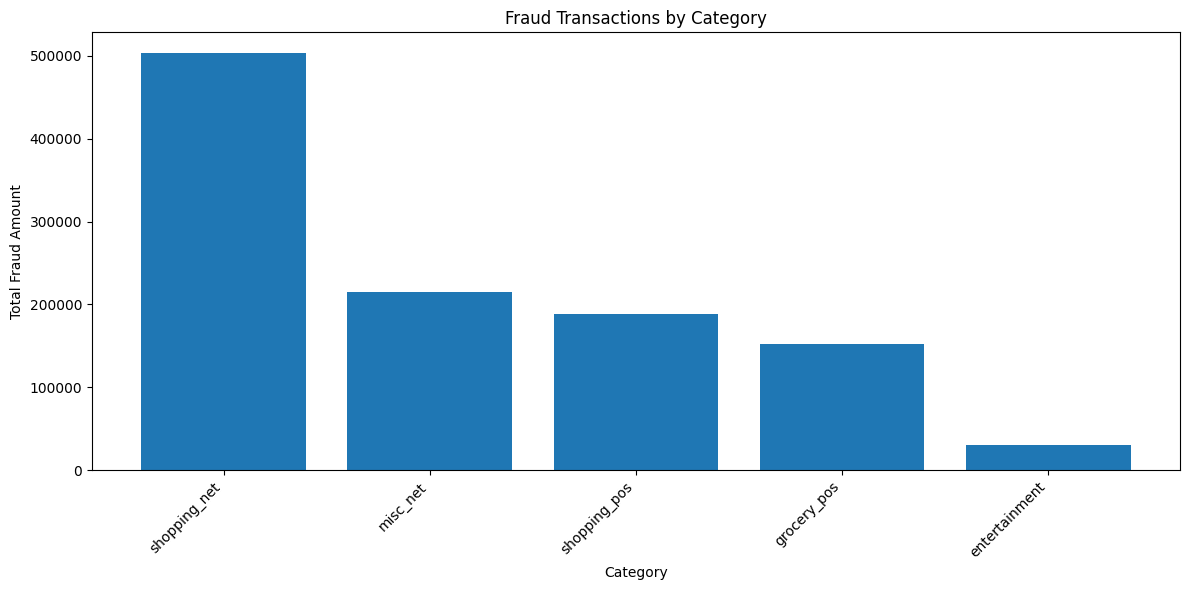

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(fraud_by_category.head(5).index, fraud_by_category.head(5).values)
plt.title('Fraud Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Total Fraud Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Online shopping channels dominate the fraud landscape, with `shopping_net` alone accounting for approximately 44% of all fraudulent transaction value — more than double the second-ranked category. The combined exposure of `shopping_net` and `misc_net`, both of which are online or card-not-present transaction types, represents over 63% of total fraud losses.

# By states

In [ ]:
fraudbystate = df[df['is_fraud'] == 1].groupby('state')['amt'].sum().sort_values(ascending=False)
fraudbystate.head(3)


,amt
state,
NY,99746.68
PA,62807.61
TX,52310.40


New York leads by a significant margin — its fraud exposure is approximately 59% higher than Pennsylvania and 90% higher than Texas. This may reflect New York's higher population density, greater volume of online retail transactions, and concentration of high-value card activity in urban centres.

## Fraudulent transactions in NY

In [ ]:
# Filtering for NY first, then grouping by category
NY_cat = df[(df['is_fraud'] == 1) & (df['state'] == 'NY')].groupby('category')['amt'].sum().sort_values(ascending=False)
NY_cat.head(5)

,amt
category,
shopping_net,47745.52
misc_net,20573.57
shopping_pos,16444.03
grocery_pos,10492.52
entertainment,2803.80


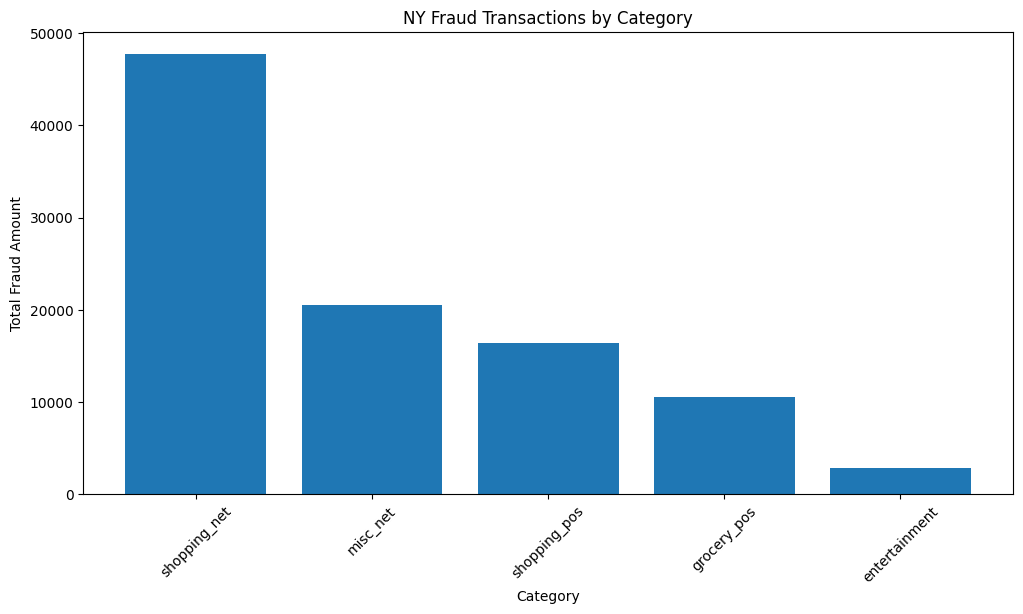

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(NY_cat.head(5).index, NY_cat.head(5).values)
plt.title('NY Fraud Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Total Fraud Amount')
plt.xticks(rotation=45)
plt.show()

## Fraudulent transactions in PA

In [ ]:
PA_cat = df[(df['is_fraud'] == 1) & (df['state'] == 'PA')].groupby('category')['amt'].sum().sort_values(ascending=False)
PA_cat.head(5)

,amt
category,
shopping_net,34175.95
misc_net,12822.94
grocery_pos,6249.63
shopping_pos,4562.34
misc_pos,2257.70


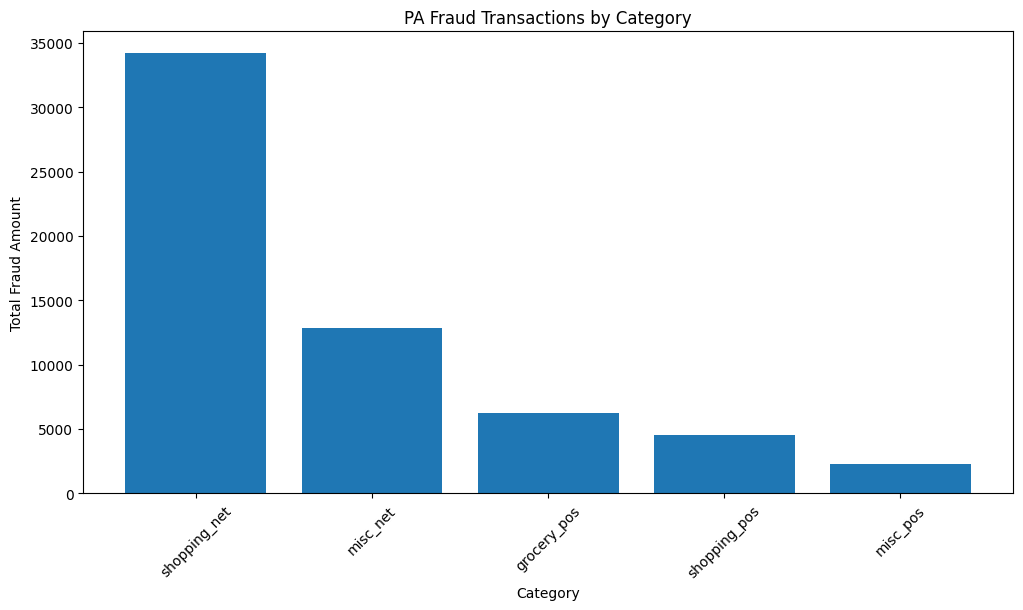

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(PA_cat.head(5).index, PA_cat.head(5).values)
plt.title('PA Fraud Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Total Fraud Amount')
plt.xticks(rotation=45)
plt.show()

## Fraudulent transactions in TX

In [ ]:
TX_cat = df[(df['is_fraud'] == 1) & (df['state'] == 'TX')].groupby('category')['amt'].sum().sort_values(ascending=False)
TX_cat.head(5)

,amt
category,
shopping_net,19974.63
misc_net,10093.78
shopping_pos,9674.02
grocery_pos,6470.75
entertainment,2584.50


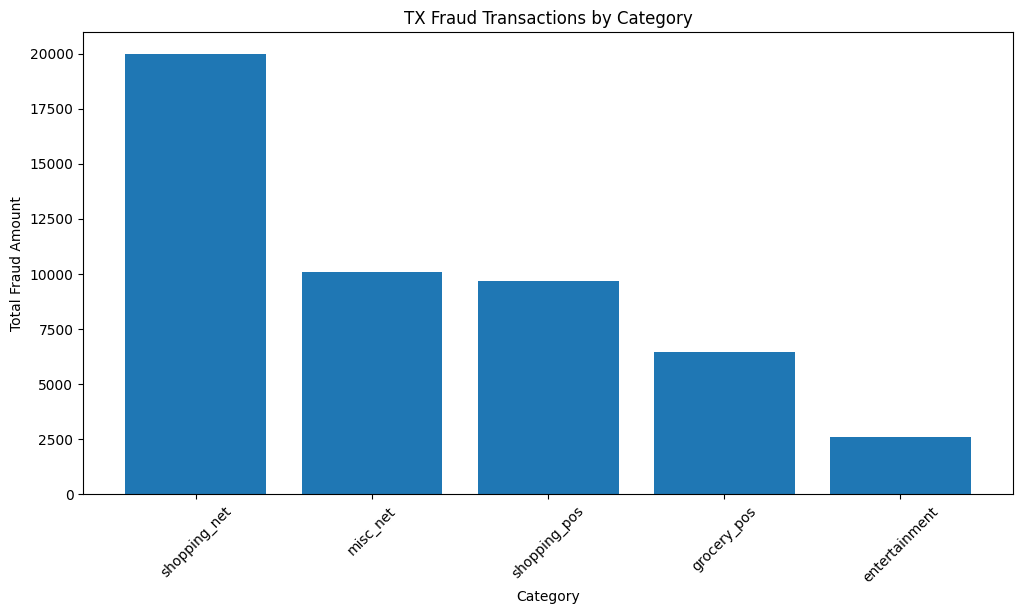

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(TX_cat.head(5).index, TX_cat.head(5).values)
plt.title('TX Fraud Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Total Fraud Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
summary_df = pd.DataFrame({
    'NY': NY_cat,
    'PA': PA_cat,
    'TX': TX_cat
})
summary_df = summary_df.rename(columns={'index': 'Category'})
summary_df.sort_values(['NY','PA','TX'], ascending = [False, False, False])

,NY,PA,TX
category,,,
shopping_net,47745.52,34175.95,19974.63
misc_net,20573.57,12822.94,10093.78
shopping_pos,16444.03,4562.34,9674.02
grocery_pos,10492.52,6249.63,6470.75
entertainment,2803.80,1493.68,2584.50
home,537.24,557.67,1224.15
food_dining,484.19,359.32,960.35
misc_pos,174.46,2257.70,920.87
gas_transport,154.09,139.79,156.11


Top 3 states:
1. New York
2. Pennsylvania
3. Texas

Top 3 categories:
1. shopping_net
2. misc_net
3. shopping_pos

Two converging findings demand immediate attention. First, online shopping channels (`shopping_net` and `misc_net`) represent a systemic and nationally consistent fraud vulnerability, contributing over 63% of total fraud losses regardless of state. Second, New York represents the bank's single highest-risk
geography by fraud exposure value.

**Recommended actions:**
- Introduce enhanced transaction verification controls for `shopping_net` and `misc_net` category transactions, particularly for high-value purchases — consider mandatory step-up authentication (e.g. OTP verification) for online purchases exceeding a defined threshold
- Deploy targeted fraud monitoring in New York, Pennsylvania, and Texas, with particular focus on online merchant transactions in those states
- Review whether the bank's card-not-present fraud controls meet current industry standards, given that CNP categories dominate fraud losses across all geographies analysed

# Gender and age distribution

In [ ]:
fraud_by_gender = df[df['is_fraud'] == 1].groupby('gender').size()
print(fraud_by_gender)

fraud_amount_by_gender = df[df['is_fraud'] == 1].groupby('gender')['amt'].sum()
print(fraud_amount_by_gender)

gender
F    1164
M     981
dtype: int64
gender
F    557459.24
M    575865.44
Name: amt, dtype: float64


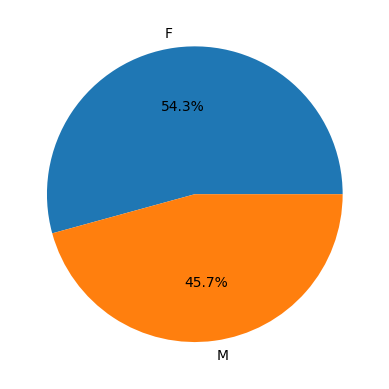

In [ ]:
plt.pie(fraud_by_gender, labels=fraud_by_gender.index, autopct='%1.1f%%')
plt.show()

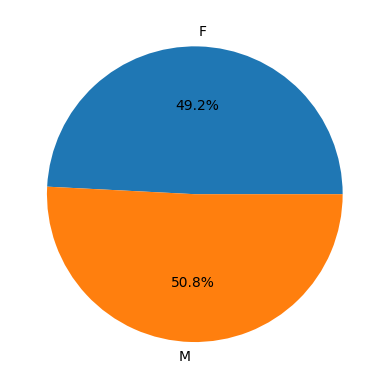

In [ ]:
plt.pie(fraud_amount_by_gender, labels=fraud_amount_by_gender.index, autopct='%1.1f%%')
plt.show()

In [ ]:
df['age'] = ((pd.Timestamp.now() - pd.to_datetime(df['dob'])).dt.days / 365).astype(int)
df['age']

,age
0,58
1,36
2,55
3,38
4,70
...,...
555714,60
555715,26
555716,44
555717,60


In [ ]:
def age_group(age):
    if 18 <= age < 30:
        return 'young adult'
    elif 30 <= age < 65:
        return 'adult'
    else:
        return 'elderly'

df['age_group'] = df['age'].apply(age_group)

fraud_by_age = df[df['is_fraud'] == 1].groupby('age_group').size().reindex(['young adult', 'adult','elderly'])
fraud_by_age

,0
age_group,
young adult,153
adult,1396
elderly,596


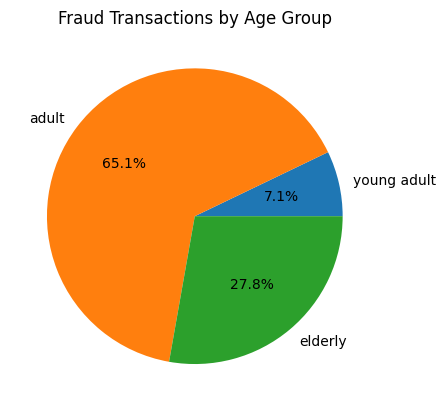

In [ ]:
plt.pie(fraud_by_age, labels = fraud_by_age.index, autopct='%1.1f%%')
plt.title('Fraud Transactions by Age Group')
plt.show()

# Regression Analysis
## The logistic regression model will be used to predict the fraud transactions and the effect of quarter, amt, and gender on fraudulent.

In [ ]:
#log amount
df['log_amt'] = np.log(df['amt'])

#encode gender
df['gender_encoded'] = df['gender'].map({'M': 0, 'F': 1})

df[['quarter','log_amt','gender','gender_encoded','is_fraud']]

,quarter,log_amt,gender,gender_encoded,is_fraud
0,2,1.050822,M,0,0
1,2,3.395850,F,1,0
2,2,3.720378,F,1,0
3,2,4.095178,M,0,0
4,2,1.160021,M,0,0
...,...,...,...,...,...
555714,4,3.778949,M,0,0
555715,4,4.717069,M,0,0
555716,4,4.464528,F,1,0
555717,4,2.078191,M,0,0


In [ ]:
#Create dummy variables

model_df = pd.get_dummies(
    df[['log_amt', 'gender_encoded', 'quarter', 'is_fraud']],
    columns=['quarter'],
    drop_first=True
)

model_df

,log_amt,gender_encoded,is_fraud,quarter_3,quarter_4
0,1.050822,0,0,False,False
1,3.395850,1,0,False,False
2,3.720378,1,0,False,False
3,4.095178,0,0,False,False
4,1.160021,0,0,False,False
...,...,...,...,...,...
555714,3.778949,0,0,False,True
555715,4.717069,0,0,False,True
555716,4.464528,1,0,False,True
555717,2.078191,0,0,False,True
